<a href="https://colab.research.google.com/github/Serge3leo/temp-cola/blob/main/valq/260325/e_cos_x_dx.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import scipy
from math import *
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = "retina"

In [2]:
a = 0.0065  # 0.0015
b = 0.0043  # 0.0010
c = 0.0039  # 0.0009
w = [1., 1., 1.]
max_nfev=1200
if False:
    a = 0.0015
    b = 0.0010
    c = 0.0009

In [3]:
if False:
    def fun(arg):
      e = np.asarray(arg[0])
      x = np.asarray(arg[1])
      dx = np.asarray(arg[2])
      return [w[0]*(a - e*np.cos(x + 0.*dx)),
              w[1]*(b - e*np.cos(x + dx)),
              w[2]*(c - e*np.cos(x + 2.*dx))]

    x0 = np.array([(a + b + c)/3, pi/2, 0.])
else:
    x0 = np.array([(a + b + c)/3, pi/2, 0.])
    def fun(arg):
      e = np.asarray(arg[0])
      x = np.asarray(arg[1])
      dx = np.asarray(arg[2])
      return [w[0]*(a + e*np.sin(x + 0.*dx)),
              w[1]*(b + e*np.sin(x + dx)),
              w[2]*(c + e*np.sin(x + 2.*dx))]

    x0 = np.array([(a + b + c)/3, 0., 0.])

In [4]:
res = scipy.optimize.least_squares(fun, x0, max_nfev=1200)
res

     message: `ftol` termination condition is satisfied.
     success: True
      status: 2
         fun: [ 3.000e-04 -6.000e-04  3.000e-04]
           x: [ 2.090e+00 -2.967e-03  6.221e-04]
        cost: 2.700005700712514e-07
         jac: [[-2.967e-03  2.090e+00  0.000e+00]
               [-2.345e-03  2.090e+00  2.090e+00]
               [-1.723e-03  2.090e+00  4.179e+00]]
        grad: [-1.994e-10  1.693e-07  1.393e-07]
  optimality: 1.692968334722915e-07
 active_mask: [ 0.000e+00  0.000e+00  0.000e+00]
        nfev: 730
        njev: 602

In [5]:
# e, x, dx
res.x

array([ 2.08965907e+00, -2.96697879e-03,  6.22109162e-04])

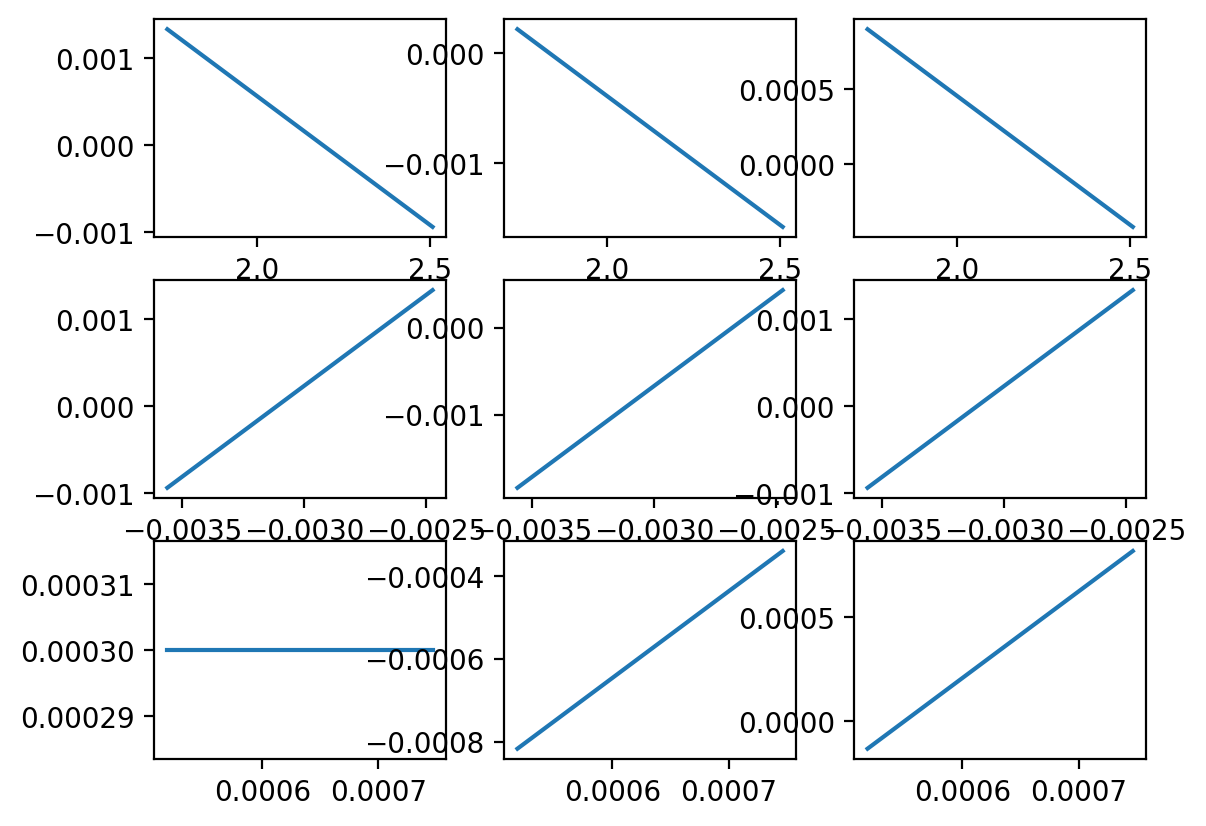

In [6]:
fig, ax = plt.subplots(3, 3)

for i in range(3):
  x = list(res.x)
  x[i] = np.linspace(res.x[i]/1.2, res.x[i]*1.2)
  f = fun(x)
  for j in range(3):
    ax[i][j].plot(x[i], f[j])

In [7]:
with np.printoptions(precision=6, suppress=True):
    print(res.x, w)
    for i in range(3):
      x1 = res.x
      w[i] = 1000.
      res1 = scipy.optimize.least_squares(fun, x1)
      print(res1.x, w)
      w[i] = 1.

[ 2.089659 -0.002967  0.000622] [1.0, 1.0, 1.0]
[ 2.318088 -0.002804  0.000638] [1000.0, 1.0, 1.0]
[ 3.656649 -0.001531  0.000356] [1.0, 1000.0, 1.0]
[ 3.134361 -0.001959  0.000357] [1.0, 1.0, 1000.0]
